<a href="https://colab.research.google.com/github/Yucheol-Son-BYUI/CSE310_W0_HelloWorld/blob/main/project_occupance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Prepraion

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv('https://raw.githubusercontent.com/Yucheol-Son-BYUI/CSE310_W0_HelloWorld/refs/heads/main/datatraining.csv')
df['date'] = pd.to_datetime(df['date'], format='mixed')
df2 = pd.read_csv('https://raw.githubusercontent.com/Yucheol-Son-BYUI/CSE310_W0_HelloWorld/refs/heads/main/datatest2.csv')
df2['date'] = pd.to_datetime(df2['date'], format='mixed')
df = pd.concat([df, df2], axis=0, ignore_index=True)
holdout = pd.read_csv("https://raw.githubusercontent.com/Yucheol-Son-BYUI/CSE310_W0_HelloWorld/refs/heads/main/datatest_holdout.csv")


In [ ]:
# 1. split 80%
split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx].copy()
final_test_df = df.iloc[split_idx:].copy()


In [3]:
print(df.isnull().sum())

i                0
date             0
Temperature      0
Humidity         0
Light            0
CO2              0
HumidityRatio    0
Occupancy        0
dtype: int64


# Data Preprocess

In [ ]:
import pandas as pd
import numpy as np

def preprocess(df):

  ## Date
  df['date'] = pd.to_datetime(df['date'])

  # cyclic hours and minute
  df['hour'] = df['date'].dt.hour
  df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
  df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

  df['minute'] = df['date'].dt.minute
  df['min_sin'] = np.sin(2 * np.pi * df['minute'] / 60)
  df['min_cos'] = np.cos(2 * np.pi * df['minute'] / 60)

  # day of week
  df['day_of_week'] = df['date'].dt.dayofweek

  """
  add trend features
  """
  def add_trend_features(df, target_cols, window=10):
    if not pd.api.types.is_datetime64_any_dtype(df['date']):
        df['date'] = pd.to_datetime(df['date'])

    for col in target_cols:
        # --- [Past Trend] ---
        val_past = df[col].shift(window).ffill().bfill()
        date_past = df['date'].shift(window).ffill().bfill()

        dt_past = (df['date'] - date_past).dt.total_seconds() / 60.0
        dt_past = dt_past.apply(lambda x: max(x, 1.0))

        df[f'{col}_past_trend_{window}'] = (df[col] - val_past) / dt_past

        val_future = df[col].shift(-window).ffill().bfill()
        date_future = df['date'].shift(-window).ffill().bfill()

        dt_future = (date_future - df['date']).dt.total_seconds() / 60.0
        dt_future = dt_future.apply(lambda x: max(x, 1.0))

        df[f'{col}_future_trend_{window}'] = (val_future - df[col]) / dt_future

    return df

  target_features = ['Temperature', 'Humidity', 'CO2', 'Light']
  df = add_trend_features(df, target_features, window=1)
  df = add_trend_features(df, target_features, window=5)
  df = df.drop(['date', 'hour', 'minute', 'i'],axis=1)
  return df

In [ ]:
preprocessed_df = preprocess(train_df)
preprocessed_df.head(5)

,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy,hour_sin,hour_cos,min_sin,min_cos,...,Light_past_trend_1,Light_future_trend_1,Temperature_past_trend_5,Temperature_future_trend_5,Humidity_past_trend_5,Humidity_future_trend_5,CO2_past_trend_5,CO2_future_trend_5,Light_past_trend_5,Light_future_trend_5
0,23.18,27.2720,426.0,721.25,0.004793,1,-0.965926,-0.258819,-0.809017,0.587785,...,0.00,3.50,0.000,-0.020000,0.0000,-0.01800,0.000000,-5.062500,0.0,-1.75
1,23.15,27.2675,429.5,714.00,0.004783,1,-0.965926,-0.258819,-0.809017,0.587785,...,3.50,-1.75,-0.030,-0.008333,-0.0045,-0.01125,-7.250000,-2.055556,3.5,-1.75
2,23.15,27.2450,426.0,713.50,0.004779,1,-0.965926,-0.258819,-0.669131,0.743145,...,-1.75,0.00,-0.015,-0.012500,-0.0135,-0.01125,-3.875000,-3.625000,0.0,-1.75
3,23.15,27.2000,426.0,708.25,0.004772,1,-0.965926,-0.258819,-0.587785,0.809017,...,0.00,0.00,-0.010,-0.012500,-0.0240,0.00000,-4.333333,-4.729167,0.0,-1.75
4,23.10,27.2000,426.0,704.50,0.004757,1,-0.965926,-0.258819,-0.500000,0.866025,...,0.00,-7.00,-0.020,-0.005000,-0.0180,-0.00500,-4.187500,-3.300000,0.0,-1.40


# Model Training

In [ ]:

ratio = (train_df['Occupancy'] == 0).sum() / (train_df['Occupancy'] == 1).sum()

sample_weights = np.ones(len(train_df))
hn_idx = train_df[(train_df['Light'] > 50) & (train_df['Occupancy'] == 0)].index
sample_weights[train_df.index.get_indexer(hn_idx)] = 5.0  # 중첩을 고려해 수치 하향 조정


In [ ]:

import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score


preprocessed_df = preprocess(df)

X = preprocessed_df.drop(['Occupancy', 'date'], axis=1, errors='ignore')
y = preprocessed_df['Occupancy']

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, shuffle=False
)

weights_train = sample_weights[:len(X_train)]
weights_val = sample_weights[len(X_train):len(X_train_full)]

model = XGBClassifier(
    scale_pos_weight=ratio,
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    early_stopping_rounds=50
)

# 6. 학습 (Validation Set 적용)
model.fit(
    X_train, y_train,
    sample_weight=weights_train,
    eval_set=[(X_val, y_val)],
    sample_weight_eval_set=[weights_val],
    verbose=50
)

print(f"\n최적의 트리 개수(Best Iteration): {model.best_iteration}")


[0]	validation_0-logloss:0.59930
[50]	validation_0-logloss:0.07907


/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [07:31:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


[100]	validation_0-logloss:0.04004
[149]	validation_0-logloss:0.04200

최적의 트리 개수(Best Iteration): 99



             Final Test Performance Report
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      2482
           1       0.98      1.00      0.99      1097

    accuracy                           0.99      3579
   macro avg       0.99      1.00      0.99      3579
weighted avg       0.99      0.99      0.99      3579



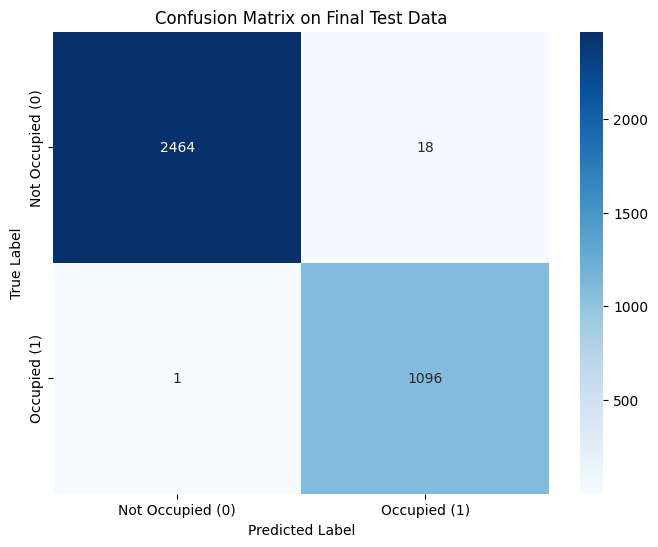

In [ ]:

# ---------------------------------------------------------
# 7. Metric Report
# ---------------------------------------------------------
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("\n" + "="*50)
print("             Final Test Performance Report")
print("="*50)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Occupied (0)', 'Occupied (1)'],
            yticklabels=['Not Occupied (0)', 'Occupied (1)'])
plt.title('Confusion Matrix on Final Test Data')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## 믿는다

             FINAL TEST SET EVALUATION
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      2482
           1       0.98      1.00      0.99      1097

    accuracy                           0.99      3579
   macro avg       0.99      1.00      0.99      3579
weighted avg       0.99      0.99      0.99      3579



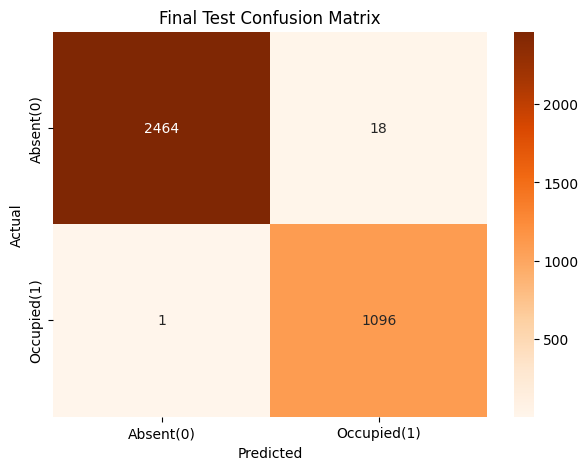

In [ ]:
test_processed = preprocess(final_test_df.copy())

X_final = test_processed.drop(['Occupancy'], axis=1, errors='ignore')
y_final = test_processed['Occupancy']

y_final_pred = model.predict(X_final)

# ---------------------------------------------------------
# 4. metric report
# ---------------------------------------------------------
print("="*60)
print("             FINAL TEST SET EVALUATION")
print("="*60)

print(classification_report(y_final, y_final_pred))

plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_final, y_final_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Absent(0)', 'Occupied(1)'],
            yticklabels=['Absent(0)', 'Occupied(1)'])
plt.title('Final Test Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

/tmp/ipykernel_7176/92848165.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importances_df.head(15), ax=ax[0], palette='viridis')
/tmp/ipykernel_7176/92848165.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=perm_df.head(15), ax=ax[1], palette='magma')


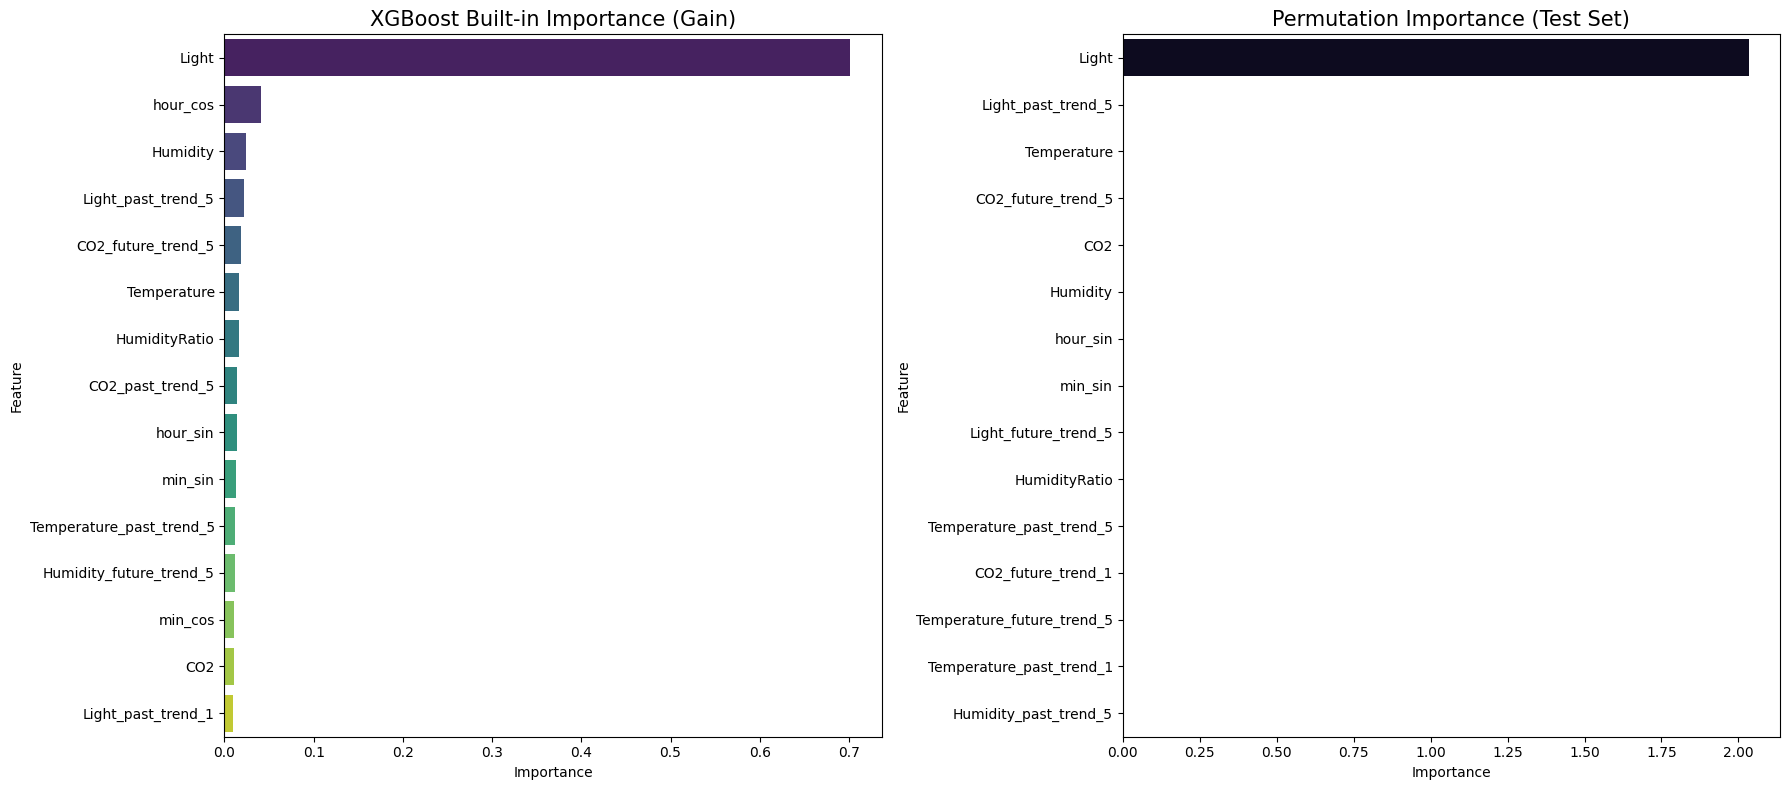

In [ ]:

from sklearn.inspection import permutation_importance

def plot_importance(model, X_test, y_test):
    importances_values = model.feature_importances_
    importances_df = pd.DataFrame({
        'Feature': X_test.columns,
        'Importance': importances_values
    }).sort_values(by='Importance', ascending=False)

    # 2. Permutation Importance 계산
    # 특정 피처를 무작위로 섞었을 때 모델 성능이 얼마나 떨어지는지 측정
    # n_repeats는 신뢰도를 위해 5~10회 권장
    perm_importance = permutation_importance(
        model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1, scoring='neg_log_loss'
    )
    perm_df = pd.DataFrame({
        'Feature': X_test.columns,
        'Importance': perm_importance.importances_mean
    }).sort_values(by='Importance', ascending=False)

    # 시각화
    fig, ax = plt.subplots(1, 2, figsize=(18, 8))

    # 왼쪽: 내장 Importance
    sns.barplot(x='Importance', y='Feature', data=importances_df.head(15), ax=ax[0], palette='viridis')
    ax[0].set_title('XGBoost Built-in Importance (Gain)', fontsize=15)

    # 오른쪽: Permutation Importance
    sns.barplot(x='Importance', y='Feature', data=perm_df.head(15), ax=ax[1], palette='magma')
    ax[1].set_title('Permutation Importance (Test Set)', fontsize=15)

    plt.tight_layout()
    plt.show()

    return importances_df, perm_df

# 실행
importances_df, perm_df = plot_importance(model, X_final, y_final)

In [ ]:
def investigate_hard_cases(df):
    total_rows = len(df)

    hard_pos = df[(df['Light'] <= 0) & (df['Occupancy'] == 1)]

    hard_neg = df[(df['Light'] > 0) & (df['Occupancy'] == 0)]

    print(f"--- [데이터셋 전체 행 수: {total_rows}] ---")
    print(f"1. Hard Positive (Light=0 & Occ=1): {len(hard_pos)}행 (전체의 {len(hard_pos)/total_rows:.2%})")
    print(f"2. Hard Negative (Light>0 & Occ=0): {len(hard_neg)}행 (전체의 {len(hard_neg)/total_rows:.2%})")

    occ_1_total = (df['Occupancy'] == 1).sum()
    occ_0_total = (df['Occupancy'] == 0).sum()

    print(f"\n--- [클래스별 예외 비중] ---")
    if occ_1_total > 0:
        print(f"- 사람이 있는 상황 중 '불 꺼진' 비중: {len(hard_pos)/occ_1_total:.2%}")
    if occ_0_total > 0:
        print(f"- 사람이 없는 상황 중 '불 켜진' 비중: {len(hard_neg)/occ_0_total:.2%}")

    return hard_pos, hard_neg

# 실행
hard_pos_df, hard_neg_df = investigate_hard_cases(preprocessed_df) # 혹은 원본 df

--- [데이터셋 전체 행 수: 17895] ---
1. Hard Positive (Light=0 & Occ=1): 1행 (전체의 0.01%)
2. Hard Negative (Light>0 & Occ=0): 2961행 (전체의 16.55%)

--- [클래스별 예외 비중] ---
- 사람이 있는 상황 중 '불 꺼진' 비중: 0.03%
- 사람이 없는 상황 중 '불 켜진' 비중: 20.97%


             FINAL TEST SET EVALUATION
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     14117
           1       0.98      1.00      0.99      3778

    accuracy                           1.00     17895
   macro avg       0.99      1.00      0.99     17895
weighted avg       1.00      1.00      1.00     17895



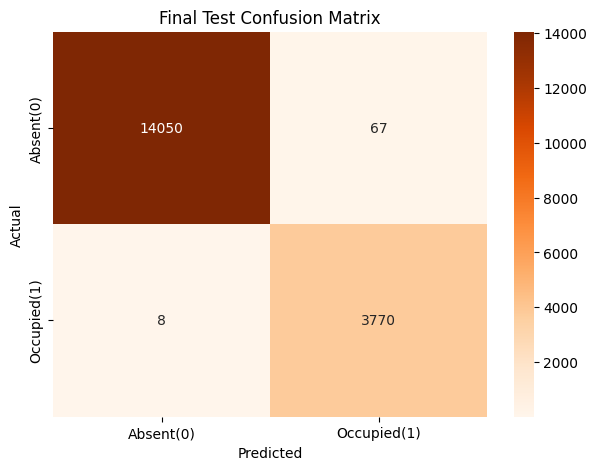

In [ ]:
total_df = preprocess(df)

X_final = total_df.drop(['Occupancy'], axis=1, errors='ignore')
y_final = total_df['Occupancy']

y_final_pred = model.predict(X_final)

# ---------------------------------------------------------
# 4. Total metric report
# ---------------------------------------------------------
print("="*60)
print("             FINAL TEST SET EVALUATION")
print("="*60)

print(classification_report(y_final, y_final_pred))

plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_final, y_final_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Absent(0)', 'Occupied(1)'],
            yticklabels=['Absent(0)', 'Occupied(1)'])
plt.title('Final Test Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
holdout = preprocess(holdout)

y_pred = model.predict(holdout)

submission_df = pd.DataFrame(y_pred, columns=['predictions'])

file_name = 'holdout_predictions.csv'
submission_df.to_csv(file_name, index=False)


In [ ]:
holdout.shape